In [29]:
from pyscf import gto, scf, cc

a = 2 # 2aB
nH = 4
atoms = ""
for i in range(nH):
    atoms += f"H {i*a:.5f} 0.00000 0.00000 \n"

mol = gto.M(atom=atoms, basis="sto6g", unit='B', spin=0, verbose=4)
mol.build()

mf = scf.RHF(mol)
mf.kernel()

mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)

nfrozen = 0
mycc = cc.CCSD(mf,frozen=nfrozen)
mycc.kernel()

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-14-generic', version='#14~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Jan 15 15:52:10 UTC 2', machine='x86_64')  Threads 16
Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
numpy 2.3.1  scipy 1.16.2  h5py 3.14.0
Date: Fri Feb 20 15:10:11 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 4
[INPUT] num. electrons = 4
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 H      0.000000000000   0.000000000000   0.000000000000 AA    

(np.float64(-0.07659940393913575),
 array([[-5.99185236e-03,  2.44156134e-17],
        [-6.49844916e-16,  4.68241594e-03]]),
 array([[[[-7.15376696e-02, -3.12817522e-16],
          [-3.12817522e-16, -6.30679402e-02]],
 
         [[-7.47020318e-16, -9.22996979e-02],
          [-5.81370139e-02,  5.42500406e-16]]],
 
 
        [[[-7.47020318e-16, -5.81370139e-02],
          [-9.22996979e-02,  5.42500406e-16]],
 
         [[-2.14223711e-01,  4.41229668e-16],
          [ 4.41229668e-16, -4.75968538e-02]]]]))

In [30]:
# example for PT2
options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 50,
            'n_walkers': 100,
            'seed': 2,
            'walker_type': 'rhf',
            'trial': 'ccsd_pt2',
            'dt':0.005,
            'free_projection':False,
            'fp_abs': False,
            'group': False,
            'ad_mode': None,
            'use_gpu': False,
            }

from ad_afqmc.prop_unrestricted import prep
import jax
jax.config.update("jax_enable_x64", True)
prep.prep_afqmc(mycc,chol_cut=1e-5)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (2, 2)
# Number of basis functions: 4
# Number of Cholesky vectors: 9
#


In [31]:
import time
import numpy as np
from jax import random
from jax import numpy as jnp
from functools import partial 

ham_data, ham, prop, trial, wave_data, sampler, options = (prep._prep_afqmc())

init_time = time.time()

### initialize propagation
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(options["seed"])

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0

e_init= jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data)[0])
# ept_sp = h0 + e0/t1 + e1/t1 - t2 * e0 / t1**2
# ept = jnp.array(jnp.sum(ept_sp) / prop.n_walkers)
prop_data["e_estimate"] = e_init
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

print(e_init)
print(e_init-mf.e_tot)

# norb: 4
# nelec: (2, 2)
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 50
# n_walkers: 100
# seed: 2
# walker_type: rhf
# trial: ccsd_pt2
# dt: 0.005
# free_projection: False
# fp_abs: False
# group: False
# use_gpu: False
# n_exp_terms: 6
# symmetry: False
# save_walkers: False
# n_batch: 1
# max_error: 0.001
-2.0886923811468114
8.237357462803629e-10


In [32]:
from ad_afqmc.prop_unrestricted import wavefunctions_restricted
amp_file="amplitudes.npz"
amplitudes = np.load(amp_file)
t1 = jnp.array(amplitudes["t1"])
t2 = jnp.array(amplitudes["t2"])
wave_data["t1"] = t1
wave_data["t2"] = t2

trial_stocc = wavefunctions_restricted.stoccsd(trial.norb, trial.nelec, n_batch=options["n_batch"])
trial_stocc.nslater = 100
wave_data['stocc'] = trial_stocc.get_stocc(wave_data, prop_data)
e_stocc = trial.calc_energy(wave_data['stocc'], ham_data, wave_data)
o_stocc = trial.calc_overlap(wave_data['stocc'], wave_data)
e_stocc = jnp.sum(o_stocc * e_stocc) / jnp.sum(o_stocc)

print(e_stocc-mycc.e_tot)

(-0.0005529315987473638+0.00014135809736928411j)


In [ ]:
# energy evaluator for <exp(T1)HF|(xtau + 1/2(xtau)^2)H|walker>
# exploitate the speed up by disconnected doubles

from jax import jit, lax, jvp
import opt_einsum as oe

# ad reference 
@jit
def _green(walker: jax.Array, slater: jax.Array) -> jax.Array:
    '''
    full green's function 
    <psi|a_p^dagger a_q|walker>/<exp(T1)HF|walker>
    '''
    green = (walker @ (
        jnp.linalg.inv(slater.T.conj() @ walker)
        ) @ slater.T.conj()).T
    return green

@jit
def _walker_olp(walker: jax.Array, slater: jax.Array):
    ''' 
    <psi|walker>
    '''
    olp = jnp.linalg.det(slater.T.conj() @ walker) ** 2
    return olp

@jit
def _ci_walker_olp(walker: jax.Array, slater: jax.Array, ci1: jax.Array, ci2: jax.Array) -> complex:
    ''' 
    <(1+ci1+ci2)psi|walker>
    = c_ia* <psi|ia|walker> + 1/2 c_iajb* <psi|ijab|walker>
    '''
    ci1 = ci1.conj()
    ci2 = ci2.conj()
    nocc = walker.shape[1]
    green_ov = _green(walker, slater)[:nocc, nocc:]
    o0 = _walker_olp(walker, slater)
    o1 = 2 * oe.contract("ia,ia-> ", ci1, green_ov, backend="jax")
    o2 = 2 * oe.contract("iajb,ia,jb->", ci2, green_ov, green_ov, backend="jax") \
        - oe.contract("iajb,ib,ja->", ci2, green_ov, green_ov, backend="jax")
    return (1.0 + o1 + o2) * o0

@jit
def _ci_exp_h1(x, h1_mod: jax.Array, walker: jax.Array, slater: jax.Array, ci1: jax.Array, ci2: jax.Array) -> complex:
    '''
    <exp(T1)HF|(1+ci1+ci2) exp(x*h1_mod)|walker>
    '''
    t = x * h1_mod
    walker_1x = walker + t.dot(walker)
    o_exp = _ci_walker_olp(walker_1x, slater, ci1, ci2)
    return o_exp 

@jit
def _ci_exp_h2(x, chol_i: jax.Array, walker: jax.Array, slater: jax.Array, ci1: jax.Array, ci2: jax.Array) -> complex:
    '''
    <exp(T1)HF|(1+ci1+ci2) exp(x*h2)|walker>
    '''
    walker_2x = (
            walker
            + x * chol_i.dot(walker)
            + x**2 / 2.0 * chol_i.dot(chol_i.dot(walker))
        )
    o_exp = _ci_walker_olp(walker_2x, slater, ci1, ci2)

    return o_exp

@jit
def _d2_ci_exp_h2i(chol_i: jax.Array, walker: jax.Array, slater: jax.Array, ci1: jax.Array, ci2: jax.Array):
    x = 0.0
    f = lambda a: _ci_exp_h2(a, chol_i, walker, slater, ci1, ci2)
    _, d2f = jax.jvp(lambda x: jax.jvp(f, [x], [1.0])[1], [x], [1.0])
    return d2f


@partial(jit, static_argnums=0)
def _calc_energy_ad(trial, walker, ham_data, wave_data, ci1, ci2):

    norb = trial.norb
    h0 = ham_data['h0']
    h1_mod = ham_data['h1_mod']
    chol = ham_data["chol"].reshape(-1, norb, norb)
    trial_slater = wave_data['mo_t']

    # o0 = _walker_olp(walker, trial_slater)

    # one body
    f1 = lambda a: _ci_exp_h1(a, h1_mod, walker, trial_slater, ci1, ci2)
    olp, d1_overlap = jvp(f1, [0.0], [1.0])

    # two body
    def scan_chol(carry, c):
        walker, trial_slater = carry
        return carry, _d2_ci_exp_h2i(c, walker, trial_slater, ci1, ci2)

    _, d2_overlap_i = lax.scan(scan_chol, (walker, trial_slater), chol)
    d2_overlap = jnp.sum(d2_overlap_i)/2

    # <psi|(1+ci1+ci2) (h1+h2)|walker> / <psi|1+ci1+ci2|walker>
    e12 = (d1_overlap + d2_overlap) / olp

    return olp, h0 + e12

In [110]:
@partial(jit, static_argnums=0)
def _calc_energy_cisd(
    trial, 
    walker: jax.Array, 
    ham_data: dict, 
    wave_data: dict,
    ci1:  jax.Array,
    ci2:  jax.Array,
    ):

    '''
    A local energy evaluator for <psi(ci1+ci2)HF|H|walker> / <psi(ci1+ci2)|walker>
    all operators and the walkers and psi are in the same basis (normally MO)
    |psi> is not necesarily diagonal
    
    all green's function and the chol and ci coeff are as their original definition
    no half rotation performed
    '''

    nocc = trial.nelec[0]
    h0  = ham_data['h0']
    trial_slater = wave_data["mo_t"]
    h1 = (ham_data["h1"][0] + ham_data["h1"][1]) / 2.0
    chol = ham_data["chol"].reshape(-1, trial.norb, trial.norb)
    green = _green(walker, trial_slater) # full green
    green_ov = green[:nocc, nocc:]
    greenp = (green - jnp.eye(trial.norb))[:, nocc:]
    
    ci1 = ci1.conj() # applied to the bra
    ci2 = ci2.conj() # applied to the bra
    
    ##################### ref terms #########################
    # one-body 
    hg = oe.contract("pq,pq->", h1, green, backend="jax")
    e1_0 = 2 * hg

    # two-body 
    gl = oe.contract("pr,gqr->gpq", green, chol, backend="jax")
    trgl = oe.contract('gpp->g', gl, backend="jax")
    e2_0_1 = 2 * jnp.sum(trgl**2)
    e2_0_2 = -oe.contract('gpq,gqp->',gl,gl, backend="jax")
    e2_0 = e2_0_1 + e2_0_2
    ##########################################################

    ######################### ci terms #######################
    # one-body single excitations 
    ci1g = oe.contract("ia,ia->", ci1, green_ov, backend="jax")
    e1_1_1 = 4 * ci1g * hg # c_ia G_ia G_pq h_pq
    gpci1 = oe.contract("pa,ia->pi", greenp, ci1, backend="jax")
    ci1_green = oe.contract("pi,iq->pq", gpci1, green[:nocc,:], backend="jax")
    e1_1_2 = -2 * oe.contract("pq,pq->", h1, ci1_green, backend="jax") # c_ia Gp_pa G_iq h_pq
    e1_1 = e1_1_1 + e1_1_2 # <psi|ci1 h1|walker> / <psi|walker>

    # one-body double excitations
    t2g_c = oe.contract("iajb,ia->jb", ci2, green_ov, backend="jax")
    t2g_e = oe.contract("iajb,ib->ja", ci2, green_ov, backend="jax")
    t2_green_c = (greenp @ t2g_c.T) @ green[:nocc,:]
    t2_green_e = (greenp @ t2g_e.T) @ green[:nocc,:]
    t2_green = 2 * t2_green_c - t2_green_e
    t2g = 2 * t2g_c - t2g_e
    gt2g = oe.contract("ia,ia->", t2g, green_ov, backend="jax")
    e1_2_1 = 2 * hg * gt2g
    e1_2_2 = -2 * oe.contract("ij,ij->", h1, t2_green, backend="jax")
    e1_2 = e1_2_1 + e1_2_2 # <exp(T1)HF|T2 h1|walker> / <exp(T1)HF|walker>

    # two-body single excitations
    e2_1_1 = 2 * e2_0 * ci1g # c_ia G_ia G_pr G_ps L_pr L_ps
    lci1g = oe.contract("gpq,pq->g", chol, ci1_green, backend="jax")
    e2_1_2 = -2 * oe.contract("g,g->",lci1g, trgl, backend="jax") # c_ia Gp_pa G_ir G_qs L_pr L_qs

    lci1 = oe.contract("gpa,ia->gpi", chol[:, :, nocc:], ci1, backend="jax")
    lg1 = oe.contract("gpr,qr->gpq", chol, green[:nocc,:], backend="jax")
    lci1g = oe.contract("gri,pr->gip", lci1, green, backend="jax")
    glgpci1 = jnp.einsum("gpr,ri->gpi", gl, gpci1, optimize="optimal")
    e2_1_3 = jnp.einsum("gpi,gpi->", glgpci1, lg1, optimize="optimal")
    e2_1 = e2_1_1 + 2 * (e2_1_2 + e2_1_3) # <exp(T1)HF|ci1 h2|walker> / <exp(T1)HF|walker>

    # two-body double excitations
    e2_2_1 = e2_0 * gt2g
    lt2g = oe.contract("gij,ij->g", chol, t2_green, backend="jax")
    e2_2_2_1 = -oe.contract("g,g->", lt2g, trgl, backend="jax")

    def scan_aux(carry, x):
        chol_i, gl_i = x
        lt2_green_i = oe.contract("pr,qr->pq",chol_i,t2_green,backend="jax")
        carry[0] += 0.5 * oe.contract("pq,pq->",gl_i,lt2_green_i,backend="jax")
        glgp_i = oe.contract("iq,qa->ia", gl_i[:nocc,:],greenp,backend="jax")
        l2t2_1 = oe.contract("ia,jb,iajb->",glgp_i,glgp_i,ci2,backend="jax")
        l2t2_2 = oe.contract("ib,ja,iajb->",glgp_i,glgp_i,ci2,backend="jax")
        carry[1] += 2 * l2t2_1 - l2t2_2
        return carry, 0.0

    [e2_2_2_2, e2_2_3], _ = lax.scan(scan_aux, [0.0, 0.0], (chol, gl))

    e2_2_2 = 4 * (e2_2_2_1 + e2_2_2_2)
    e2_2 = e2_2_1 + e2_2_2 + e2_2_3

    o0 = _walker_olp(walker, trial_slater)
    olp = (1.0 + 2*ci1g +  gt2g) * o0 # <(1+c1+c2)psi|walker>
    # <exp(T1)HF|h1+h2|walker> + <exp(T1)ci1 HF|(h1+h2)|walker> + <exp(T1)ci2 HF|(h1+h2)|walker>
    e = h0 + (e1_0 + e2_0 + e1_1 + e2_1 + e1_2 + e2_2) / (1.0 + 2*ci1g +  gt2g)

    return olp, e

In [35]:
def get_xtau(trial, wave_data: dict, prop_data: dict):
    nslater = trial.nslater

    # t_iajb = tau_gia tau_gjb
    tau, _ = trial.decompose_t2(wave_data)

    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            nslater,
            tau.shape[0],
        ),
    )

    xtau = jnp.einsum("sg,gia->sia", fields, tau) # (nslater,nocc,nvir)

    return xtau

In [92]:
@partial(jit, static_argnums=0)
def _exp_tau(trial, init_slater, t):
    # calculate exp(t_ia a+ i)|psi>
    t_full = jnp.eye(trial.norb,dtype=jnp.complex128)
    exp_t = t_full.at[:trial.nelec[0], trial.nelec[0]:].set(t)
    # exp_tau = jsp.linalg.expm(t_full)
    return exp_t.T @ init_slater

@partial(jit, static_argnums=0)
def _exp_tau2(trial, init_slater, t):
    # calculate exp(t_ia a+ i)|psi>
    from jax import scipy as jsp
    t_full = jnp.zeros((trial.norb, trial.norb) ,dtype=jnp.complex128)
    t_full = t_full.at[:trial.nelec[0], trial.nelec[0]:].set(t)
    exp_t = jsp.linalg.expm(t_full)
    return exp_t.T @ init_slater

@partial(jit, static_argnums=0)
def _calc_energy_slater(trial, slater: jax.Array, walker: jax.Array, ham_data: dict) -> jax.Array:
    norb = trial.norb

    h0, chol = ham_data["h0"], ham_data["chol"]
    h1 = (ham_data["h1"][0] + ham_data["h1"][1]) / 2.0
    chol = chol.reshape(-1,norb,norb)

    green = _green(walker, slater)
    hg = oe.contract("pq,pq->", h1, green, backend="jax")
    e1 = 2 * hg
    lg = oe.contract("gpr,qr->gpq", chol, green, backend="jax")
    e2_1 = 2 * jnp.sum(oe.contract('gpp->g', lg, backend="jax")**2)
    e2_2 = -oe.contract('gpq,gqp->',lg,lg, backend="jax")
    e2 = e2_1 + e2_2

    overlap = _walker_olp(walker, slater)

    return overlap, h0 + e1 + e2

@partial(jit, static_argnums=0)
def _calc_energy_exp_xtau(trial, walker: jax.Array, ham_data: dict, wave_data: dict, xtau: jax.Array) -> jax.Array:
    # norb = trial.norb
    # nocc = trial.nelec[0]
    
    # init_sd = jnp.eye(norb, dtype=jnp.complex128)[:,:nocc]
    # t = wave_data['t1'] + xtau
    slater = _exp_tau(trial, wave_data['mo_t'], xtau)

    # overlap = _walker_olp(walker, slater)
    overlap, energy = _calc_energy_slater(trial, slater, walker, ham_data)

    return overlap, energy

@partial(jit, static_argnums=0)
def _calc_energy_ci_xtau(trial, walker: jax.Array, ham_data: dict, wave_data: dict, xtau: jax.Array) -> jax.Array:
    # norb = trial.norb
    # nocc = trial.nelec[0]
    ci1 = xtau
    ci2 = oe.contract('ia,jb->iajb', xtau, xtau, backend='jax')
    overlap, energy = _calc_energy_cisd(trial, walker, ham_data, wave_data, ci1, ci2)

    return overlap, energy

In [132]:
@partial(jit, static_argnums=0)
def _calc_exp_ci_xtau(trial, walker, ham_data, wave_data, xtau):
    o_exp, e_exp = _calc_energy_exp_xtau(trial, walker, ham_data, wave_data, xtau)
    o_ci, e_ci =  _calc_energy_ci_xtau(trial, walker, ham_data, wave_data, xtau)
    do = o_exp - o_ci
    de = o_exp*e_exp - o_ci*e_ci
    return (do, de)

@partial(jit, static_argnums=0)
def _calc_exp_xtaus(trial, walker, ham_data, wave_data):

    def _scan_xtaus(carry, xtau: jax.Array):
        (overlap, energy) = _calc_energy_exp_xtau(trial, walker, ham_data, wave_data, xtau)
        return carry, (overlap, energy)

    init_carry = 0.0
    _, (overlaps, energies) = lax.scan(_scan_xtaus, init_carry, wave_data['xtau'])

    exp_tau_energy = jnp.sum(overlaps*energies) / jnp.sum(overlaps)

    return exp_tau_energy

@partial(jit, static_argnums=0)
def _calc_exp_ci_xtaus(trial, walker, ham_data, wave_data):
    
    def _scan_xtaus(carry, xtau: jax.Array):
        (do, de) = _calc_exp_ci_xtau(trial, walker, ham_data, wave_data, xtau)
        return carry, (do, de)

    init_carry = 0.0
    _, (dos, des) = lax.scan(_scan_xtaus, init_carry, wave_data['xtau'])

    do = jnp.sum(dos) / wave_data['xtau'].shape[0] # intermediately normalize the stocc
    de = jnp.sum(des) / wave_data['xtau'].shape[0]

    return do, de

In [122]:
walker = prop_data['walkers'][0]
xtau = get_xtau(trial_stocc, wave_data, prop_data)
print(xtau.shape)
wave_data['xtau'] = xtau
_calc_exp_xtaus(trial, walker, ham_data, wave_data) - mycc.e_tot

(100, 2, 2)


Array(0.00308829+0.00047988j, dtype=complex128)

In [126]:
@partial(jit, static_argnums=0)
def get_stocc1(trial, walker, ham_data, wave_data):
    energy = _calc_exp_xtaus(trial, walker, ham_data, wave_data)
    return energy

@partial(jit, static_argnums=0)
def get_stocc2(trial, walker, ham_data, wave_data):
    ci1 = wave_data['t1'] * 0
    ci2 = wave_data['t2']
    ocisd, ecisd = _calc_energy_cisd(trial, walker, ham_data, wave_data, ci1, ci2)
    do, de = _calc_exp_ci_xtaus(trial, walker, ham_data, wave_data)
    energy = (ocisd*ecisd + de) / (ocisd + do)
    return energy

In [133]:
ci1 = wave_data['t1'] * 0
ci2 = wave_data['t2']
ocisd, ecisd = _calc_energy_cisd(trial, walker, ham_data, wave_data, ci1, ci2)
print(ocisd, ecisd)
# print(ecisd - mycc.e_tot)

-0.0013331631936087415 -0.847412161532151


In [124]:
nsample = 100
energy1 = np.zeros(nsample, dtype='complex128')
energy2 = np.zeros(nsample, dtype='complex128')

ci1 = wave_data['t1'] * 0
ci2 = wave_data['t2']
ocisd, ecisd = _calc_energy_cisd(trial, walker, ham_data, wave_data, ci1, ci2)

for n in range(nsample):
    wave_data['xtau'] = get_xtau(trial_stocc, wave_data, prop_data)
    # energy1[n] = get_stocc1(trial, prop_data['walkers'][0], ham_data, wave_data)
    # energy2[n] = get_stocc2(trial, prop_data['walkers'][0], ham_data, wave_data)
    # print(f'{n}  {energy1[n]}  {energy2[n]}')
    do, de = _calc_exp_ci_xtaus(trial, walker, ham_data, wave_data)
    energy = (ecisd * ocisd + de) / (ocisd + do)
    print(do, de, energy)

0j (1.4654943925052067e-16-6.822968974746005e-18j) (-2.1652917860941465-6.823363534084594e-18j)
0j (2.575717417130363e-16-2.214777942995304e-17j) (-2.165291786094146-2.214906019397753e-17j)
0j (1.687538997430238e-16-3.7644261758349245e-20j) (-2.1652917860941465-3.764643865451805e-20j)
0j (1.8207657603852569e-16-4.995546213021687e-18j) (-2.1652917860941465-4.9958350959723485e-18j)
0j (2.531308496145357e-16-6.49113534732966e-18j) (-2.165291786094146-6.491510717359747e-18j)
0j (2.220446049250313e-16-7.642227711659837e-18j) (-2.1652917860941465-7.64266964717536e-18j)
0j (1.9984014443252818e-16+2.070812808678394e-17j) (-2.1652917860941465+2.0709325598505243e-17j)
0j (1.9539925233402755e-16+1.915321064726791e-17j) (-2.1652917860941465+1.9154318241066562e-17j)
0j (2.6201263381153693e-16-9.259361838734065e-19j) (-2.165291786094146-9.259897290045124e-19j)
0j (2.708944180085382e-16+9.507072388993849e-18j) (-2.165291786094146+9.507622164935613e-18j)
0j (5.773159728050814e-17+5.814610132357651e-18

In [102]:
nsample = 100
energy1 = np.zeros(nsample, dtype='complex128')
energy2 = np.zeros(nsample, dtype='complex128')

for n in range(nsample):
    wave_data['xtau'] = get_xtau(trial_stocc, wave_data, prop_data)
    energy1[n] = get_stocc1(trial, prop_data['walkers'][0], ham_data, wave_data)
    energy2[n] = get_stocc2(trial, prop_data['walkers'][0], ham_data, wave_data)
    print(f'{n}  {energy1[n]}  {energy2[n]}')

0  (-2.1782652447750603-0.0001522897830398119j)  (-2.1652917860941185+9.363237050041927e-16j)
1  (-2.160023592982125-0.0003692392541946497j)  (-2.165291786094116+2.8322184314874526e-16j)
2  (-2.1619709112692576-0.00036918769534460816j)  (-2.165291786094129-8.896850681264192e-16j)
3  (-2.182613554997684-0.0005355127214483245j)  (-2.1652917860941283+1.356807551100944e-15j)
4  (-2.1561091150487437-3.939067427273077e-05j)  (-2.165291786094116-5.932049103866663e-16j)
5  (-2.164734775519108+0.00014678987419326032j)  (-2.165291786094128+1.3797016344111912e-16j)
6  (-2.15796701179849+0.0002062417386699335j)  (-2.165291786094124+8.30767190330948e-16j)
7  (-2.1680133974241422+5.974500507553343e-05j)  (-2.1652917860941225+6.368395829717341e-16j)
8  (-2.1597844268420943+0.0001774472372709261j)  (-2.1652917860941057-1.0658111900026873e-16j)
9  (-2.1686296613212708-0.00018562435197600873j)  (-2.1652917860941177+1.5223282072191077e-15j)
10  (-2.1797066223360884+5.957023005146959e-05j)  (-2.1652917860

/home/sharmagroup/miniconda3/envs/lno_pyscf_afqmc/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/sharmagroup/miniconda3/envs/lno_pyscf_afqmc/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


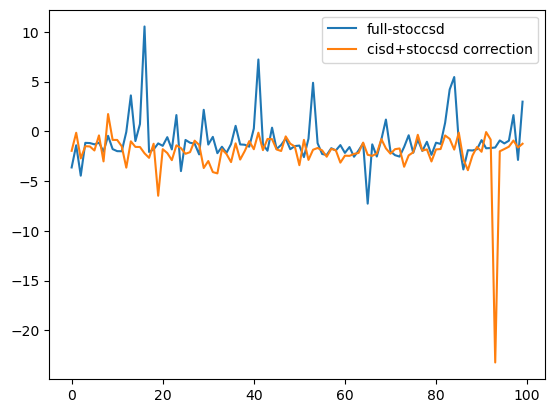

In [130]:
from matplotlib import pyplot as plt
plt.plot(energy1,label='full-stoccsd')
plt.plot(energy2,label='cisd+stoccsd correction')
plt.legend()
plt.show()

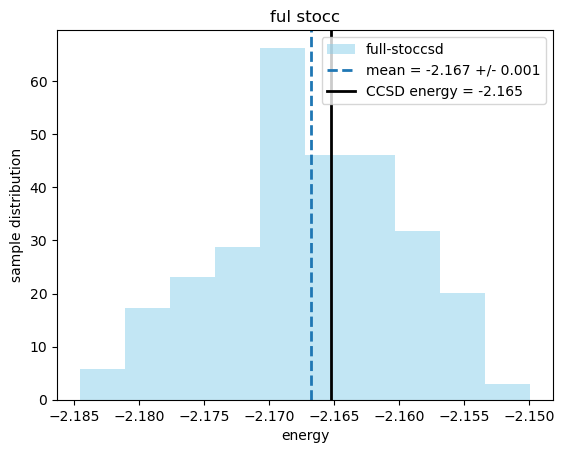

In [104]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(energy1.real, bins=10, alpha=0.5, density=True, color='skyblue', label='full-stoccsd')
mean = np.mean(energy1.real)
sigma = np.std(energy1.real)/np.sqrt(len(energy1))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.3f}")
plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("sample distribution")
plt.title("ful stocc")
plt.legend()
plt.show()

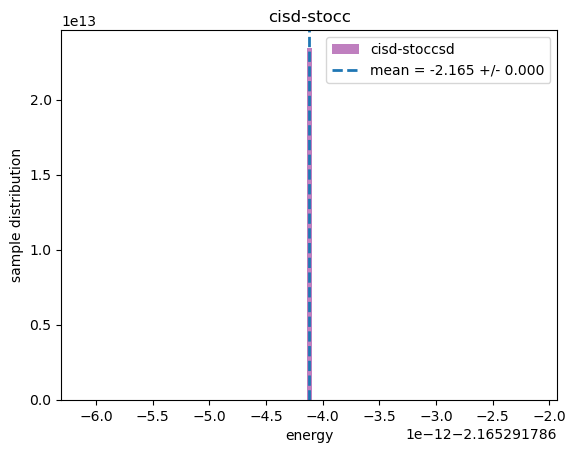

In [105]:
plt.figure()
plt.hist(energy2.real, bins=1, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
mean = np.mean(energy2.real)
sigma = np.std(energy2.real)/np.sqrt(len(energy2))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.3f}")
# plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("sample distribution")
plt.title("cisd-stocc")
plt.legend()
plt.show()

In [134]:
nsample = 100
energy1 = np.zeros(nsample, dtype='complex128')
energy2 = np.zeros(nsample, dtype='complex128')
walker = jnp.array(np.random.rand(*prop_data['walkers'][0].shape))

ocisd, ecisd = _calc_energy_cisd(trial, walker, ham_data, wave_data, ci1, ci2)
print(ocisd, ecisd)

for n in range(nsample):
    wave_data['xtau'] = get_xtau(trial_stocc, wave_data, prop_data)
    energy1[n] = get_stocc1(trial, walker, ham_data, wave_data)
    # energy2[n] = get_stocc2(trial, walker, ham_data, wave_data)
    do, de = _calc_exp_ci_xtaus(trial, walker, ham_data, wave_data)
    energy2[n] = (ecisd * ocisd + de) / (ocisd + do)
    print(f'{n}  {energy1[n]}  {energy2[n]}')

0.3592988140447008 -2.1895944376137026
0  (-2.1374460631748455-0.14983837650787207j)  (-2.1638947560275277-0.02327372266943053j)
1  (-2.4716427328360306+0.08675710899954991j)  (-2.165132178414702-0.012304890306848044j)
2  (-2.046625683575513-0.36410192322930196j)  (-2.172904317818487+0.005766342335475844j)
3  (-2.4988638094816644-0.14166391386207627j)  (-2.172163993113154+0.023452264794476874j)
4  (-2.178258293090738-0.05747672370598509j)  (-2.1596058510505194+0.008706701949448017j)
5  (-2.1398484349563174-0.10739797328556058j)  (-2.1727868946338877-0.027284692916447716j)
6  (-2.251580108939216-0.007452040528809172j)  (-2.170198480637413+0.00935488951012949j)
7  (-2.1456508027268573+0.09427034631002949j)  (-2.1735606748533605+0.005749466340407498j)
8  (-2.167175552238513+0.025815604457469284j)  (-2.1619855044627183-0.026465350339094505j)
9  (-2.1008612116707677+0.36496425780291947j)  (-2.1659185311259797-0.0354721748962879j)
10  (-2.301397664795997-0.18331544986445597j)  (-2.1722618655

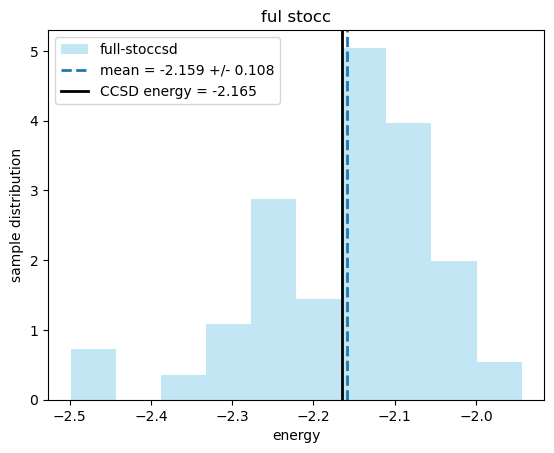

In [139]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(energy1.real, bins=10, alpha=0.5, density=True, color='skyblue', label='full-stoccsd')
mean = np.mean(energy1.real)
sigma = np.std(energy1.real)
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.3f}")
plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("sample distribution")
plt.title("ful stocc")
plt.legend()
plt.show()

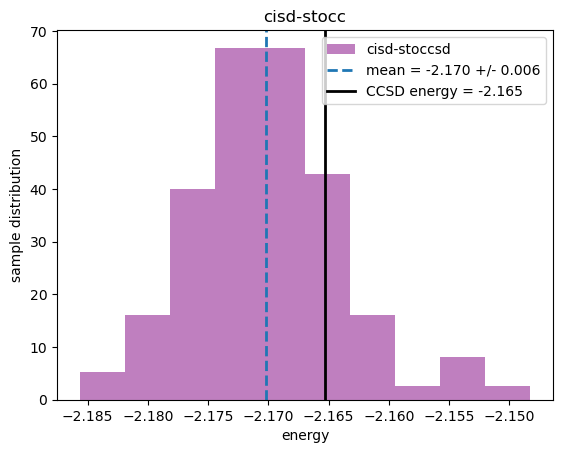

In [138]:
plt.figure()
plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
mean = np.mean(energy2.real)
sigma = np.std(energy2.real)
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.3f}")
plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("sample distribution")
plt.title("cisd-stocc")
plt.legend()
plt.show()

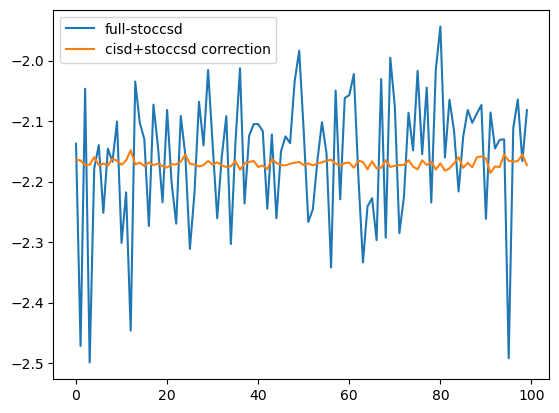

In [137]:
from matplotlib import pyplot as plt
plt.plot(energy1.real,label='full-stoccsd')
plt.plot(energy2.real,label='cisd+stoccsd correction')
plt.legend()
plt.show()